In [2]:
import torch
import numpy as np
import os

from diffusion import immap2
from training.common import load_model
from datasets.fastmri.common import load_knee_data
from models import NormUnet
from operators import Mask, Sense, FFT2D
from physics.mask import make_acc_mask
from visualization.image import plot_image
from physics.nle import whiten_from_kspace

/home/ee2178/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:
os.chdir('/scratch/ee2178/ImMAP')

In [4]:
# GPU Settings
device = 'cuda'
# UNet Checkpoint
unet_path = '/home/ee2178/scratch/ee2178/ImMAP/trained_nets/knee/NormUNetLog/config.json'
# LPDSNet Checkpoint
# unet_path = '/home/ee2178/scratch/ee2178/ImMAP/trained_nets/knee/LPDSNet/config.json'

In [7]:
fname = 'file1000052.h5'
kspace, smaps, knee_mask, gnd_truth = load_knee_data(kspace_fname = fname, slice_idx=15, device=device)

Loading slice 15 from /home/ee2178/scratch/ee2178/datasets/fastmri/knee/multicoil_val/file1000052.h5


In [8]:
# Mask generation
mask = make_acc_mask(shape=kspace[0,0].shape, accel = 6, acs_lines=20, device = device)

In [9]:
net = load_model(unet_path, device=device)
# net.eval()

In [10]:
# Try whitening first
kspace_w, image_w, smaps_w, sigma_n, smaps_w, Zinv = whiten_from_kspace(kspace, smaps, mask = mask, R = 6, gnd_truth_kspace = kspace)

In [11]:
# Construct operator
E = Mask(mask) @ FFT2D() @ Sense(smaps)

In [12]:
# Constructing measurement/simulated kspace
meas_kspace = mask*kspace
sim_kspace = E(E.H(kspace))

In [13]:
zf_recon = E.H(kspace)

In [14]:
sigma_y = sigma_n

In [15]:
sigma_y

tensor(0.0176, device='cuda:0')

In [16]:
# save_dir = None
save_dir = "/home/ee2178/scratch/ee2178/ImMAP/figs"

In [23]:
recon = immap2(meas_kspace, sigma_y, net, E, lam = 2.0, sigma_max = 1.0, sigma_min = 0.01, save_dir = save_dir, verbose = True, use_rest=False, lam_min = 1e-9, ws = None)

Iteration 1 complete. Noise level: 0.9864597320556641. p_t: 0.0012600983027368784 Tolerance Reached: True
Iteration 2 complete. Noise level: 0.9880179166793823. p_t: 0.0012580855982378125 Tolerance Reached: True
Iteration 3 complete. Noise level: 0.9852936267852783. p_t: 0.001261610770598054 Tolerance Reached: True
Iteration 4 complete. Noise level: 0.9858929514884949. p_t: 0.0012608328834176064 Tolerance Reached: True
Saved image to /home/ee2178/scratch/ee2178/ImMAP/figs/immap2_sigma_0.987.png.
Iteration 5 complete. Noise level: 0.9868418574333191. p_t: 0.0012596038868650794 Tolerance Reached: True
Iteration 6 complete. Noise level: 0.9862499833106995. p_t: 0.0012603700160980225 Tolerance Reached: True
Iteration 7 complete. Noise level: 0.9842734336853027. p_t: 0.001262938603758812 Tolerance Reached: True
Iteration 8 complete. Noise level: 0.9814298748970032. p_t: 0.0012666612165048718 Tolerance Reached: True
Iteration 9 complete. Noise level: 0.9775398373603821. p_t: 0.00127180642448

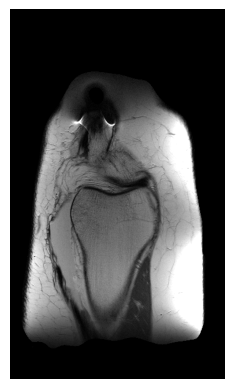

In [18]:
plot_image(gnd_truth, contrast=True)

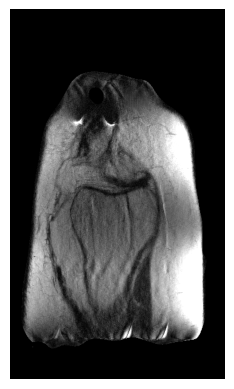

In [24]:
plot_image(
    recon*Zinv,
    contrast=True,
    thresh=1.0
)